In [1]:
import numpy as np
import pandas as pd

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
df=pd.read_csv('gurgaon_feature engeenerring 1 approach 2.csv')

In [4]:
df.sample(5)

,society,price,area_persqft,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,furnishDetails,features,sector,area,type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
3446,mian wali,1.7,9444.0,1.0,1.0,1,servant room,1.0,NaN,Old Property,NaN,['Visitor Parking'],sector 12,1797.0,house,NaN,1800.0,NaN,0,1,0,0,0
2662,signature global orchard avenue,0.4,7359.0,2.0,2.0,2,not avilable,11.0,NaN,New Property,"['1 Fan', '1 Exhaust Fan', '1 Geyser', '5 Ligh...","['Security / Fire Alarm', 'Lift(s)', 'Maintena...",sector 93,543.552sq-ft,flat,NaN,NaN,543.57695,0,0,0,0,0
2527,central park flower valley,2.5,13270.0,3.0,3.0,2,not avilable,1.0,NaN,Undefined,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,sector 33,1883.949sq-ft,flat,NaN,NaN,1884.00000,0,0,0,0,0
3321,NaN,NaN,7500.0,NaN,NaN,NaN,not avilable,NaN,NaN,Undefined,NaN,NaN,sector 21,4004.0,house,NaN,4004.0,NaN,0,0,0,0,0
2818,signature global park 4,0.72,6428.0,3.0,2.0,3,not avilable,2.0,NaN,Undefined,NaN,NaN,sector 36,1120.1sq-ft,flat,NaN,NaN,1120.00000,0,0,0,0,0


## furnishDetails

In [5]:
df['furnishDetails'].value_counts()

furnishDetails
[]                                                                                                                                                                                                                                                                       439
['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']     214
['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']      75
['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fri

In [6]:
df['furnishDetails'].dtypes

dtype('O')

In [7]:
import re
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [8]:
furnishings_df

,furnishDetails,Sofa,Bed,Chimney,TV,Wardrobe,Stove,AC,Modular Kitchen,Curtains,Exhaust Fan,Geyser,Fan,Dining Table,Light,Fridge,Microwave,Water Purifier,Washing Machine
0,"['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...",0,0,0,0,1,0,0,0,0,0,0,3,0,4,0,0,0,0
1,"['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...",0,0,1,0,3,0,0,1,1,1,1,4,0,3,0,0,0,0
2,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,[],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,[],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,[],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

/var/folders/9h/szcjr1mj4c51q1_y7hpk6bvm0000gn/T/ipykernel_28480/114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [10]:
furnishings_df.sample(5)

,Sofa,Bed,Chimney,TV,Wardrobe,Stove,AC,Modular Kitchen,Curtains,Exhaust Fan,Geyser,Fan,Dining Table,Light,Fridge,Microwave,Water Purifier,Washing Machine
431,0,0,1,0,3,0,0,1,0,0,2,5,0,5,0,0,0,0
1793,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1493,0,0,1,0,4,1,5,1,1,1,5,7,0,12,0,0,0,0
164,0,0,1,0,4,0,0,1,0,0,1,3,0,5,0,0,0,0
1664,0,0,1,0,0,0,0,1,0,0,0,7,0,7,0,0,0,0


In [11]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)


In [12]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

/Users/abhijeetkashyap/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/abhijeetkashyap/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/abhijeetkashyap/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/abhijeetkashyap/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppre

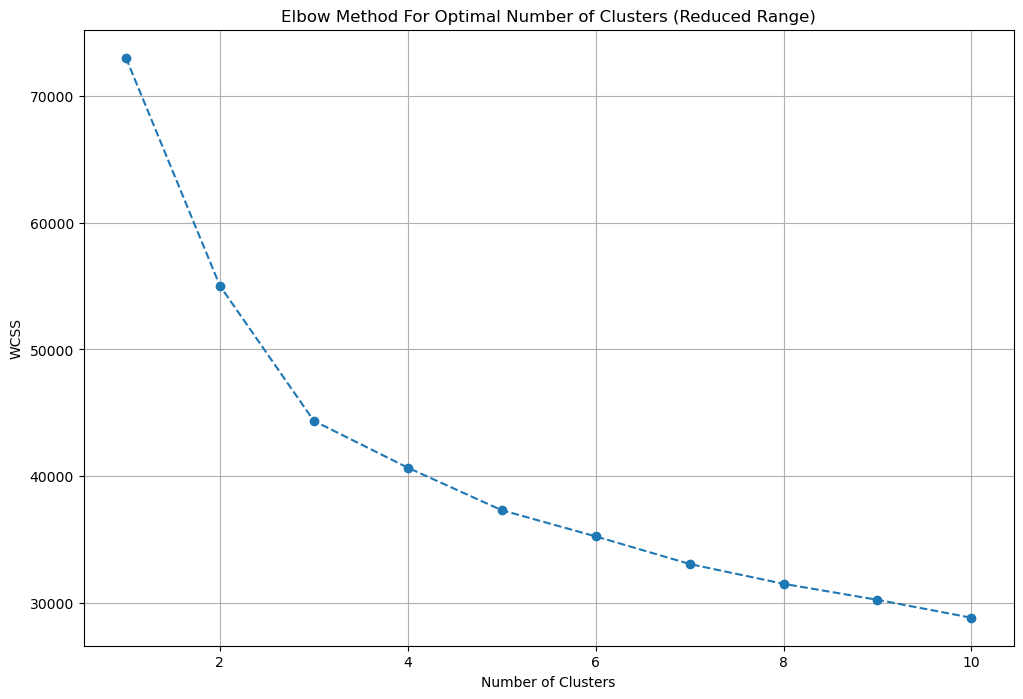

In [13]:
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [14]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters,init='k-means++',random_state=42 )
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

/Users/abhijeetkashyap/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [15]:
cluster_assignments

array([2, 0, 2, ..., 2, 2, 2], dtype=int32)

In [16]:
df['furnishing_type'] = cluster_assignments
df.sample(5)[['furnishDetails','furnishing_type']]


,furnishDetails,furnishing_type
284,NaN,2
3714,"['8 Wardrobe', '9 Fan', '1 Exhaust Fan', '9 Li...",0
319,NaN,2
3919,NaN,2
3168,[],2


In [17]:
df['furnishing_type'].value_counts()

furnishing_type
2    2725
0    1107
1     225
Name: count, dtype: int64

In [23]:
df[df['furnishing_type']==0][['furnishDetails','furnishing_type']]

,furnishDetails,furnishing_type
1,"['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...",0
19,"['1 Wardrobe', '1 Fan', '1 Exhaust Fan', '1 Ge...",0
23,"['5 Wardrobe', '8 Fan', '1 Exhaust Fan', '20 L...",0
28,"['6 Fan', '1 Exhaust Fan', '4 Geyser', '55 Lig...",0
32,"['7 Fan', '11 Light', '7 AC', '1 Modular Kitch...",0
39,"['2 Wardrobe', '3 Fan', '1 Exhaust Fan', '1 Ge...",0
46,"['8 Fan', '1 Exhaust Fan', '6 Geyser', '1 Stov...",0
50,"['1 Fan', '1 Exhaust Fan', '1 Geyser', '1 Ligh...",0
55,"['4 Wardrobe', '7 Fan', '1 Exhaust Fan', '2 Ge...",0
57,"['1 Wardrobe', '2 Fan', '1 Exhaust Fan', '1 Ge...",0


In [25]:
df.drop(columns=['Sofa', 'Bed',
       'Chimney', 'TV', 'Wardrobe', 'Stove', 'AC', 'Modular Kitchen',
       'Curtains', 'Exhaust Fan', 'Geyser', 'Fan', 'Dining Table', 'Light',
       'Fridge', 'Microwave', 'Water Purifier', 'Washing Machine','furnishDetails'],axis=1,inplace=True)

In [26]:
df.columns

Index(['society', 'price', 'area_persqft', 'bedRoom', 'bathroom', 'balcony',
       'additionalRoom', 'floorNum', 'facing', 'agePossession', 'features',
       'sector', 'area', 'type', 'super_built_up_area', 'built_up_area',
       'carpet_area', 'study room', 'servant room', 'store room', 'pooja room',
       'others', 'furnishing_type'],
      dtype='object')

In [27]:
df.sample(5)

,society,price,area_persqft,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,features,sector,area,type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type
3568,NaN,2.43,14890.0,4.0,4.0,2,"pooja room,study room,store room",3.0,South-West,Old Property,"['Water Storage', 'Park', 'Visitor Parking', '...",sector 7,(152 sq.m.) Plot Area,house,NaN,345.0,NaN,1,0,1,1,0,2
251,shyamkunj ashok vihar pahse 2,0.3,4444.0,2.0,2.0,1,not avilable,1.0,East,Relatively New,"['High Ceiling Height', 'Maintenance Staff', '...",sector 3 phase 2,675.068sq-ft,flat,NaN,NaN,675.0,0,0,0,0,0,2
2190,trisara our homes 3,0.35,5564.0,2.0,2.0,1,not avilable,2.0,North,New Property,"['Security / Fire Alarm', 'Intercom Facility',...",sohna road,629.044sq-ft,flat,NaN,NaN,629.0,0,0,0,0,0,2
3552,NaN,1.85,16003.0,4.0,3.0,2,not avilable,3.0,NaN,Undefined,NaN,sector 1,(107 sq.m.) Carpet Area,house,NaN,NaN,1156.0,0,0,0,0,0,2
3461,NaN,0.47,8012.0,2.0,1.0,1,store room,1.0,East,Moderately Old,NaN,sector 4,624.0,house,NaN,624.0,NaN,0,0,1,0,0,2


## features

In [30]:
df['features'].head(5)

0    ['Feng Shui / Vaastu Compliant', 'Security / F...
1    ['Security / Fire Alarm', 'Maintenance Staff',...
2    ['Power Back-up', 'Feng Shui / Vaastu Complian...
3    ['Security / Fire Alarm', 'Private Garden / Te...
4                                                  NaN
Name: features, dtype: object

In [31]:
df['features'].value_counts()

features
['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              290
['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for ser

In [32]:
df['features'].isnull().sum()

794

In [28]:
df2=pd.read_excel('/Users/abhijeetkashyap/Desktop/project version 1/real_estate_data.xlsx',)

In [33]:
df2.head()

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Pa...","{'Bajghera Road': '800 Meter', 'Palam Vihar Ha...",https://www.99acres.com/smartworld-one-dxp-sec...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Salon', 'Restaurant', 'Spa'..."
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap Un...","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The N...",https://www.99acres.com/m3m-crown-sector-111-g...,"{'3 BHK': {'building_type': 'Apartment', 'area...","['Bowling Alley', 'Mini Theatre', 'Manicured G..."
2,Adani Brahma Samsara Vilasa,"Land, 3, 4 BHK Independent Floor in Sector 63,...","['AIPL Business Club Sector 62', 'Heritage Xpe...","{'AIPL Business Club Sector 62': '2.7 Km', 'He...",https://www.99acres.com/adani-brahma-samsara-v...,{'3 BHK': {'building_type': 'Independent Floor...,"['Terrace Garden', 'Gazebo', 'Fountain', 'Amph..."
3,Sobha City,"2, 3, 4 BHK Apartment in Sector 108, Gurgaon","['The Shikshiyan School', 'WTC Plaza', 'Luxus ...","{'The Shikshiyan School': '2.9 KM', 'WTC Plaza...",https://www.99acres.com/sobha-city-sector-108-...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Volley Ball Court', 'Aerobi..."
4,Signature Global City 93,"2, 3 BHK Independent Floor in Sector 93 Gurgaon","['Pranavananda Int. School', 'DLF Site central...","{'Pranavananda Int. School': '450 m', 'DLF Sit...",https://www.99acres.com/signature-global-city-...,{'2 BHK': {'building_type': 'Independent Floor...,"['Mini Theatre', 'Doctor on Call', 'Concierge ..."


In [34]:
df2['PropertyName'] = df2['PropertyName'].str.lower()

In [36]:
temp=df[df['features'].isnull()]

In [37]:
temp.shape

(794, 23)

In [39]:
x = temp.merge(df2,left_on='society',right_on='PropertyName',how='left')['TopFacilities']
df.loc[temp.index,'features'] = x.values

0                                                    NaN
1                                                    NaN
2                                                    NaN
3                                                    NaN
4                                                    NaN
5      ['Swimming Pool', 'Volley Ball Court', 'Aerobi...
6                                                    NaN
7      ['Swimming Pool', 'Lounge', 'Aerobics Centre',...
8                                                    NaN
9                                                    NaN
10     ['Mini Theatre', 'Doctor on Call', 'Beach Voll...
11     ['Mini Theatre', 'Foosball', 'Swimming Pool', ...
12                                                   NaN
13                                                   NaN
14     ['Swimming Pool', 'School', 'Sauna', 'Steam Ro...
15                                                   NaN
16                                                   NaN
17                             

In [41]:
df['features'].isnull().sum()

591

In [42]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theater Home,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
3159,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
387,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0
827,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
473,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0
3434,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [43]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [44]:
luxury_score

0        28
1        37
2        36
3        76
4         0
5         0
6         0
7        60
8        58
9       100
10       49
11       44
12        0
13        0
14       15
15       59
16        0
17       49
18      104
19       49
20       38
21       49
22       45
23       95
24       72
25        0
26        0
27       34
28       49
29       42
30       60
31        0
32      119
33       14
34        0
35       60
36       72
37       83
38      109
39      103
40       15
41       67
42       49
43      130
44        0
45       46
46      102
47       97
48      110
49       72
50       38
51       52
52       49
53       16
54       46
55       44
56        9
57       22
58       37
59        0
60        0
61       80
62       37
63       97
64      109
65       62
66       51
67       55
68       60
69       50
70        0
71       49
72       37
73       43
74       90
75       44
76       42
77      111
78        0
79       95
80       75
81       61
82       15
83  

In [45]:
df['luxury_score'] = luxury_score

In [46]:
df.sample(5)

,society,price,area_persqft,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,features,sector,area,type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
3427,NaN,1.0,11111.0,3.0,4.0,2,not avilable,2.0,NaN,Relatively New,NaN,sector 3 phase 2,904.0,house,NaN,900.0,NaN,0,0,0,0,0,2,[],0
3441,not applicable,0.8,54794.0,5.0,4.0,3,not avilable,3.0,NaN,Under Construction,NaN,sector 4,151.0,house,NaN,146.0,NaN,0,0,0,0,0,2,[],0
2890,valley view estate,0.38,6089.0,1.0,1.0,1,not avilable,11.0,NaN,Moderately Old,"['Feng Shui / Vaastu Compliant', 'Security / F...",gwal pahari,624.076sq-ft,flat,624.0,NaN,NaN,0,0,0,0,0,2,"[Feng Shui / Vaastu Compliant, Security / Fire...",42
1581,ss the leaf,1.18,10094.0,2.0,3.0,3,pooja room,12.0,North,Relatively New,"['Centrally Air Conditioned', 'Water purifier'...",sector 85,1169.011sq-ft,flat,1671.0,1420.0,1169.000000,0,0,0,1,0,0,"[Centrally Air Conditioned, Water purifier, Se...",150
2566,mvn athens,0.26,5397.0,2.0,2.0,1,not avilable,5.0,NaN,Relatively New,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",sohna road,481.749sq-ft,flat,NaN,NaN,481.684525,0,0,0,0,0,2,"[Security / Fire Alarm, Power Back-up, Feng Sh...",95


In [47]:
df.drop(columns=['features',],axis=1,inplace=True)

In [48]:
df.sample(5)

,society,price,area_persqft,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,sector,area,type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
3467,jacobpura,0.53,14583.0,4.0,4.0,2,not avilable,3.0,East,Relatively New,sector 12,355.0,house,NaN,360.0,NaN,0,0,0,0,0,2,[],0
3617,NaN,0.8,8155.0,5.0,4.0,1,not avilable,2.0,NaN,Moderately Old,sector 3,979.0,house,NaN,981.0,NaN,0,0,0,0,0,2,[],0
3567,NaN,0.6,6000.0,1.0,1.0,0,not avilable,1.0,NaN,Undefined,sector 3,(93 sq.m.) Built-up Area,house,NaN,1000.0,NaN,0,0,0,0,0,2,[],0
1670,adani oyster greens,1.9,10058.0,3.0,3.0,3+,"pooja room,study room,store room",9.0,North-East,Relatively New,sector 102,1889.044sq-ft,flat,NaN,NaN,1889.0,1,0,1,1,0,2,[],0
1854,nagata group housing society,0.85,3695.0,3.0,3.0,3+,servant room,4.0,North,Relatively New,sector 1,2300.406sq-ft,flat,2300.0,NaN,NaN,0,1,0,0,0,2,"[Feng Shui / Vaastu Compliant, Piped-gas]",5


In [49]:
df.drop(columns=['features_list'],axis=1,inplace=True)

In [50]:
df.sample(5)

,society,price,area_persqft,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,sector,area,type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1584,m3m woodshire,1.45,6141.0,3.0,4.0,3+,servant room,7.0,South,Relatively New,sector 107,2361.179sq-ft,flat,2361.0,1900.000000,NaN,0,1,0,0,0,2,67
2450,sare green parc,0.75,4820.0,3.0,2.0,2,not avilable,16.0,NaN,Undefined,sector 92,1556.017sq-ft,flat,NaN,1556.000000,1261.000000,0,0,0,0,0,2,0
3086,international city by sobha phase 1,NaN,11100.0,NaN,NaN,NaN,not avilable,NaN,NaN,Undefined,sector 109,3154.0,house,NaN,3154.000000,NaN,0,0,0,0,0,2,54
1595,experion the heartsong,0.9,7014.0,2.0,3.0,3,servant room,2.0,South,Relatively New,sector 108,1283.148sq-ft,flat,1283.0,978.223232,734.420897,0,1,0,0,0,2,94
3460,NaN,0.32,7111.0,2.0,3.0,1,not avilable,1.0,North-East,Relatively New,sector 8,(42 sq.m.) Built-up Area,house,NaN,450.000000,300.000000,0,0,0,0,0,2,0


In [51]:
df.columns

Index(['society', 'price', 'area_persqft', 'bedRoom', 'bathroom', 'balcony',
       'additionalRoom', 'floorNum', 'facing', 'agePossession', 'sector',
       'area', 'type', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

In [52]:
df[['study room', 'servant room', 'store room', 'pooja room', 'others']].sample(5)

,study room,servant room,store room,pooja room,others
2372,0,0,0,0,0
943,0,0,1,0,0
3719,0,1,0,1,0
1802,0,0,0,0,0
195,0,0,0,0,0


In [53]:
temp_df=df[['study room', 'servant room', 'store room', 'pooja room', 'others']]

In [61]:
df[df['others']==2]

,society,price,area_persqft,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,sector,area,type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
